In [1]:
!pip install -q chromadb sentence-transformers scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [3]:
from sentence_transformers import SentenceTransformer
from chromadb import PersistentClient

# Free embedding model
embed = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

print('Embedding dim:', embed.get_sentence_embedding_dimension())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dim: 384


/tmp/ipykernel_979/3322200865.py:7: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print('Embedding dim:', embed.get_sentence_embedding_dimension())


In [4]:
sample_text = """
Operating Systems: Process management, threads, scheduling algorithms.

Memory management: paging, segmentation, virtual memory, page replacement.

File systems: directory structures, file allocation methods.

Synchronisation: critical section, semaphores, monitors.

Deadlocks: prevention, avoidance, detection, recovery.

Database Management Systems: ER model, relational model, normalisation.

SQL: DDL, DML, joins, subqueries, views, triggers.

Transactions: ACID, concurrency control, locking.

Indexing: B+ trees, hashing.

Computer Networks: TCP/IP, routing, congestion control.
"""

with open("cse_sem5.txt", "w") as f:
    f.write(sample_text)

print("File created")

File created


In [5]:
with open('cse_sem5.txt') as f:
    text = f.read()

# Split into paragraphs
paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()][:10]

print(f'Loaded {len(paragraphs)} paragraphs')

for i, p in enumerate(paragraphs):
    print(f'[{i+1}] {p[:80]}')

Loaded 10 paragraphs
[1] Operating Systems: Process management, threads, scheduling algorithms.
[2] Memory management: paging, segmentation, virtual memory, page replacement.
[3] File systems: directory structures, file allocation methods.
[4] Synchronisation: critical section, semaphores, monitors.
[5] Deadlocks: prevention, avoidance, detection, recovery.
[6] Database Management Systems: ER model, relational model, normalisation.
[7] SQL: DDL, DML, joins, subqueries, views, triggers.
[8] Transactions: ACID, concurrency control, locking.
[9] Indexing: B+ trees, hashing.
[10] Computer Networks: TCP/IP, routing, congestion control.


In [6]:
client = PersistentClient(path='./chroma_db')

col = client.get_or_create_collection('hello_syllabus')

In [7]:
vectors = embed.encode(paragraphs).tolist()

print("Generated embeddings")
print("Total vectors:", len(vectors))

Generated embeddings
Total vectors: 10


In [8]:
col.add(
    documents=paragraphs,
    embeddings=vectors,
    ids=[f'p{i}' for i in range(len(paragraphs))]
)

print(f'Indexed {col.count()} documents')

Indexed 10 documents


In [9]:
queries = [
    'what is dynamic programming?',
    'machine learning topics',
    'operating system processes',
]

for q in queries:

    print(f'\nQuery: {q}')

    qv = embed.encode([q]).tolist()

    results = col.query(
        query_embeddings=qv,
        n_results=3
    )

    docs = results['documents'][0]
    distances = results['distances'][0]

    for j, (d, dist) in enumerate(zip(docs, distances)):
        print(f'[{j+1}] (dist={dist:.3f}) {d[:80]}')


Query: what is dynamic programming?
[1] (dist=1.503) SQL: DDL, DML, joins, subqueries, views, triggers.
[2] (dist=1.540) Operating Systems: Process management, threads, scheduling algorithms.
[3] (dist=1.540) Memory management: paging, segmentation, virtual memory, page replacement.

Query: machine learning topics
[1] (dist=1.436) Indexing: B+ trees, hashing.
[2] (dist=1.556) Memory management: paging, segmentation, virtual memory, page replacement.
[3] (dist=1.594) Operating Systems: Process management, threads, scheduling algorithms.

Query: operating system processes
[1] (dist=0.515) Operating Systems: Process management, threads, scheduling algorithms.
[2] (dist=1.213) Transactions: ACID, concurrency control, locking.
[3] (dist=1.324) Memory management: paging, segmentation, virtual memory, page replacement.


In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

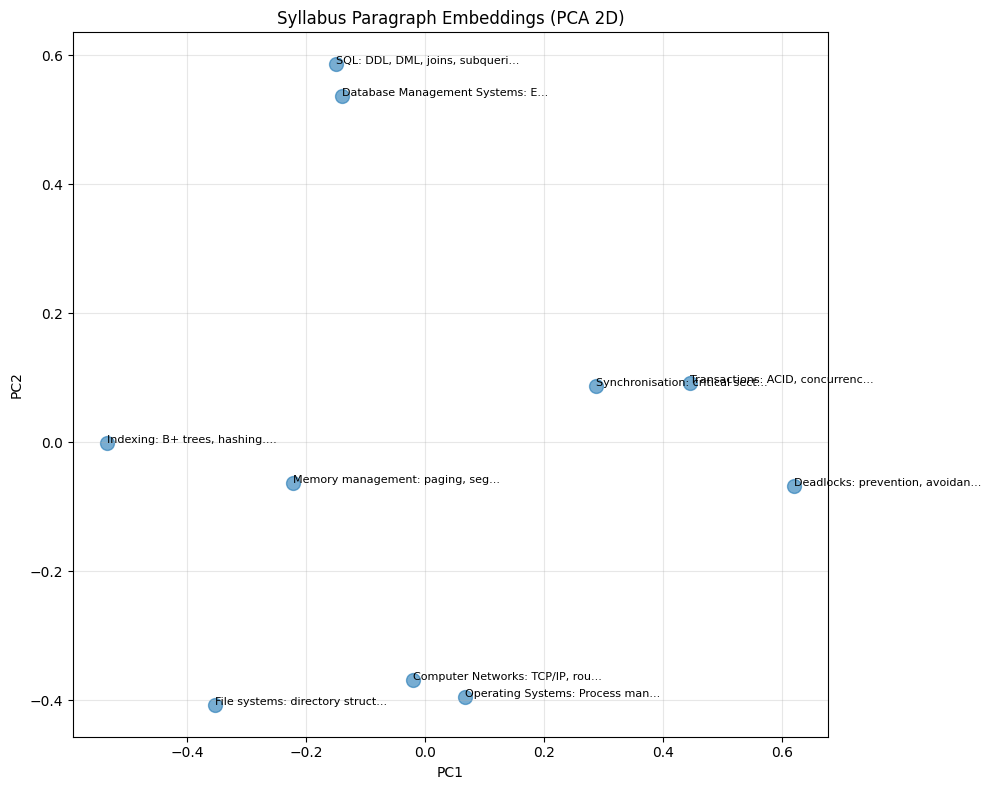

In [11]:
vectors_arr = np.array(vectors)

pca = PCA(n_components=2)

xy = pca.fit_transform(vectors_arr)

plt.figure(figsize=(10, 8))

plt.scatter(xy[:, 0], xy[:, 1], s=100, alpha=0.6)

for i, p in enumerate(paragraphs):

    label = p[:30] + '...'

    plt.annotate(label, (xy[i, 0], xy[i, 1]), fontsize=8)

plt.title('Syllabus Paragraph Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [12]:
outlier = "Today's special at the cafeteria is butter chicken with rice and naan."

col.add(
    documents=[outlier],
    embeddings=embed.encode([outlier]).tolist(),
    ids=['outlier_food']
)

print("Outlier added")

Outlier added


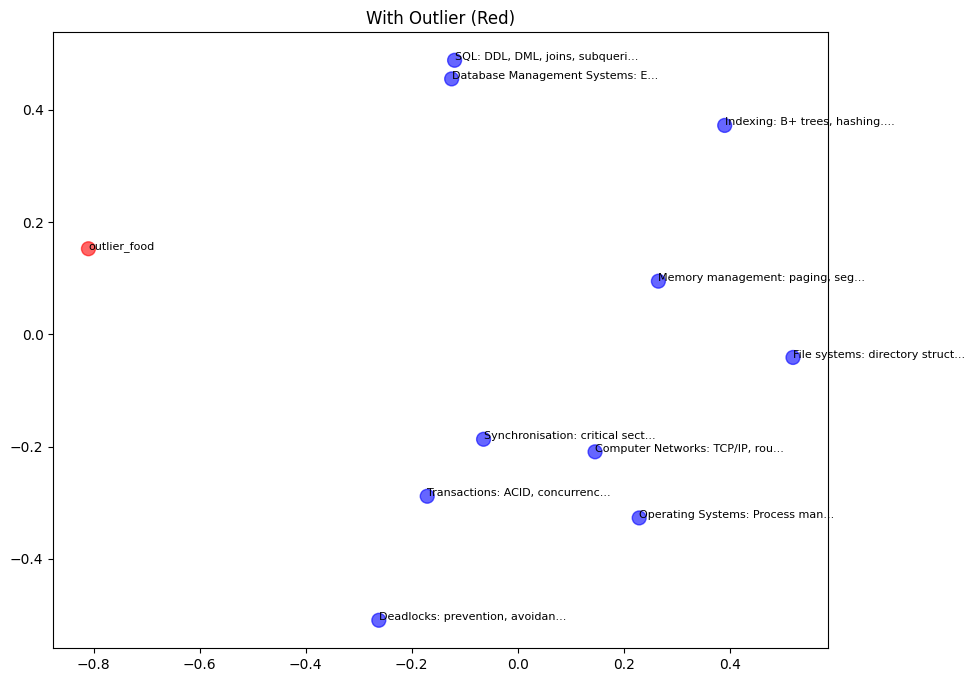

In [13]:
all_docs = col.get(include=['embeddings', 'documents'])

all_vecs = np.array(all_docs['embeddings'])

labels = all_docs['ids']

pca = PCA(n_components=2)

xy = pca.fit_transform(all_vecs)

plt.figure(figsize=(10, 8))

colors = ['red' if 'outlier' in l else 'blue' for l in labels]

plt.scatter(xy[:, 0], xy[:, 1], c=colors, s=100, alpha=0.6)

for i, l in enumerate(labels):

    short = labels[i] if 'outlier' in labels[i] else all_docs['documents'][i][:30] + '...'

    plt.annotate(short, (xy[i, 0], xy[i, 1]), fontsize=8)

plt.title('With Outlier (Red)')

plt.show()

## Day 7 Lab 7A — ChromaDB Hello-World

- Embedded 10 syllabus paragraphs using MiniLM-L6-v2
- Stored embeddings in ChromaDB
- Performed semantic search
- Visualized embeddings using PCA
- Observed semantic clustering

Reflection:
Semantic search returns nearest meaning, not exact truth.
RAG systems need citation validation for correctness.